In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw

plt.rcParams['figure.dpi'] = 300

In [2]:
# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS_ORIGINAL = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
PATH_TO_DOCKING_RESULTS_REAL = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [3]:
import random
random.seed(42)
POCKETS_TO_ANALYZE = set(random.sample([f'{i.replace(".pdb", "")}_pocket_{j}' for i,j in zip(pocket_detection_data['File name'], pocket_detection_data['Pocket number'])], 10))

In [4]:
DOCKING_RESULTS_ORIGINAL = {}
DOCKING_RESULTS_REAL = {}
DOCKING_RESULTS_REAL_BACKGROUND = {}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_ORIGINAL))[:]):
    if pocket in POCKETS_TO_ANALYZE:
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_ORIGINAL, pocket, 'report.csv'))
        DOCKING_RESULTS_ORIGINAL[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL))[:]):
    if pocket in POCKETS_TO_ANALYZE:
        try:
            scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL, pocket, 'report.csv'))
            DOCKING_RESULTS_REAL[pocket] = {i: j for i, j in zip(scores['compound'][:100000], scores['score'][:100000])}
            DOCKING_RESULTS_REAL_BACKGROUND[pocket] = {i: j for i, j in zip(scores['compound'][100000:], scores['score'][100000:])}
        except:
            pass

100%|██████████| 276/276 [00:10<00:00, 27.32it/s]


In [5]:
print(len(DOCKING_RESULTS_ORIGINAL['alphafold3_P9WFT1_model_4_pocket_2']))
print(len(DOCKING_RESULTS_REAL['alphafold3_P9WFT1_model_4_pocket_2']))
print(len(DOCKING_RESULTS_REAL_BACKGROUND['alphafold3_P9WFT1_model_4_pocket_2']))

100154
100000
12958


In [6]:
def simple_boxplot(ax, x, y, c, width):
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[0, 99], showfliers=False,
               boxprops=dict(facecolor=c, color='black', lw=0.9),
               medianprops=dict(color='black', lw=0.9),
               whiskerprops=dict(color='black', lw=0.9),
               capprops=dict(color='none', lw=0.9))

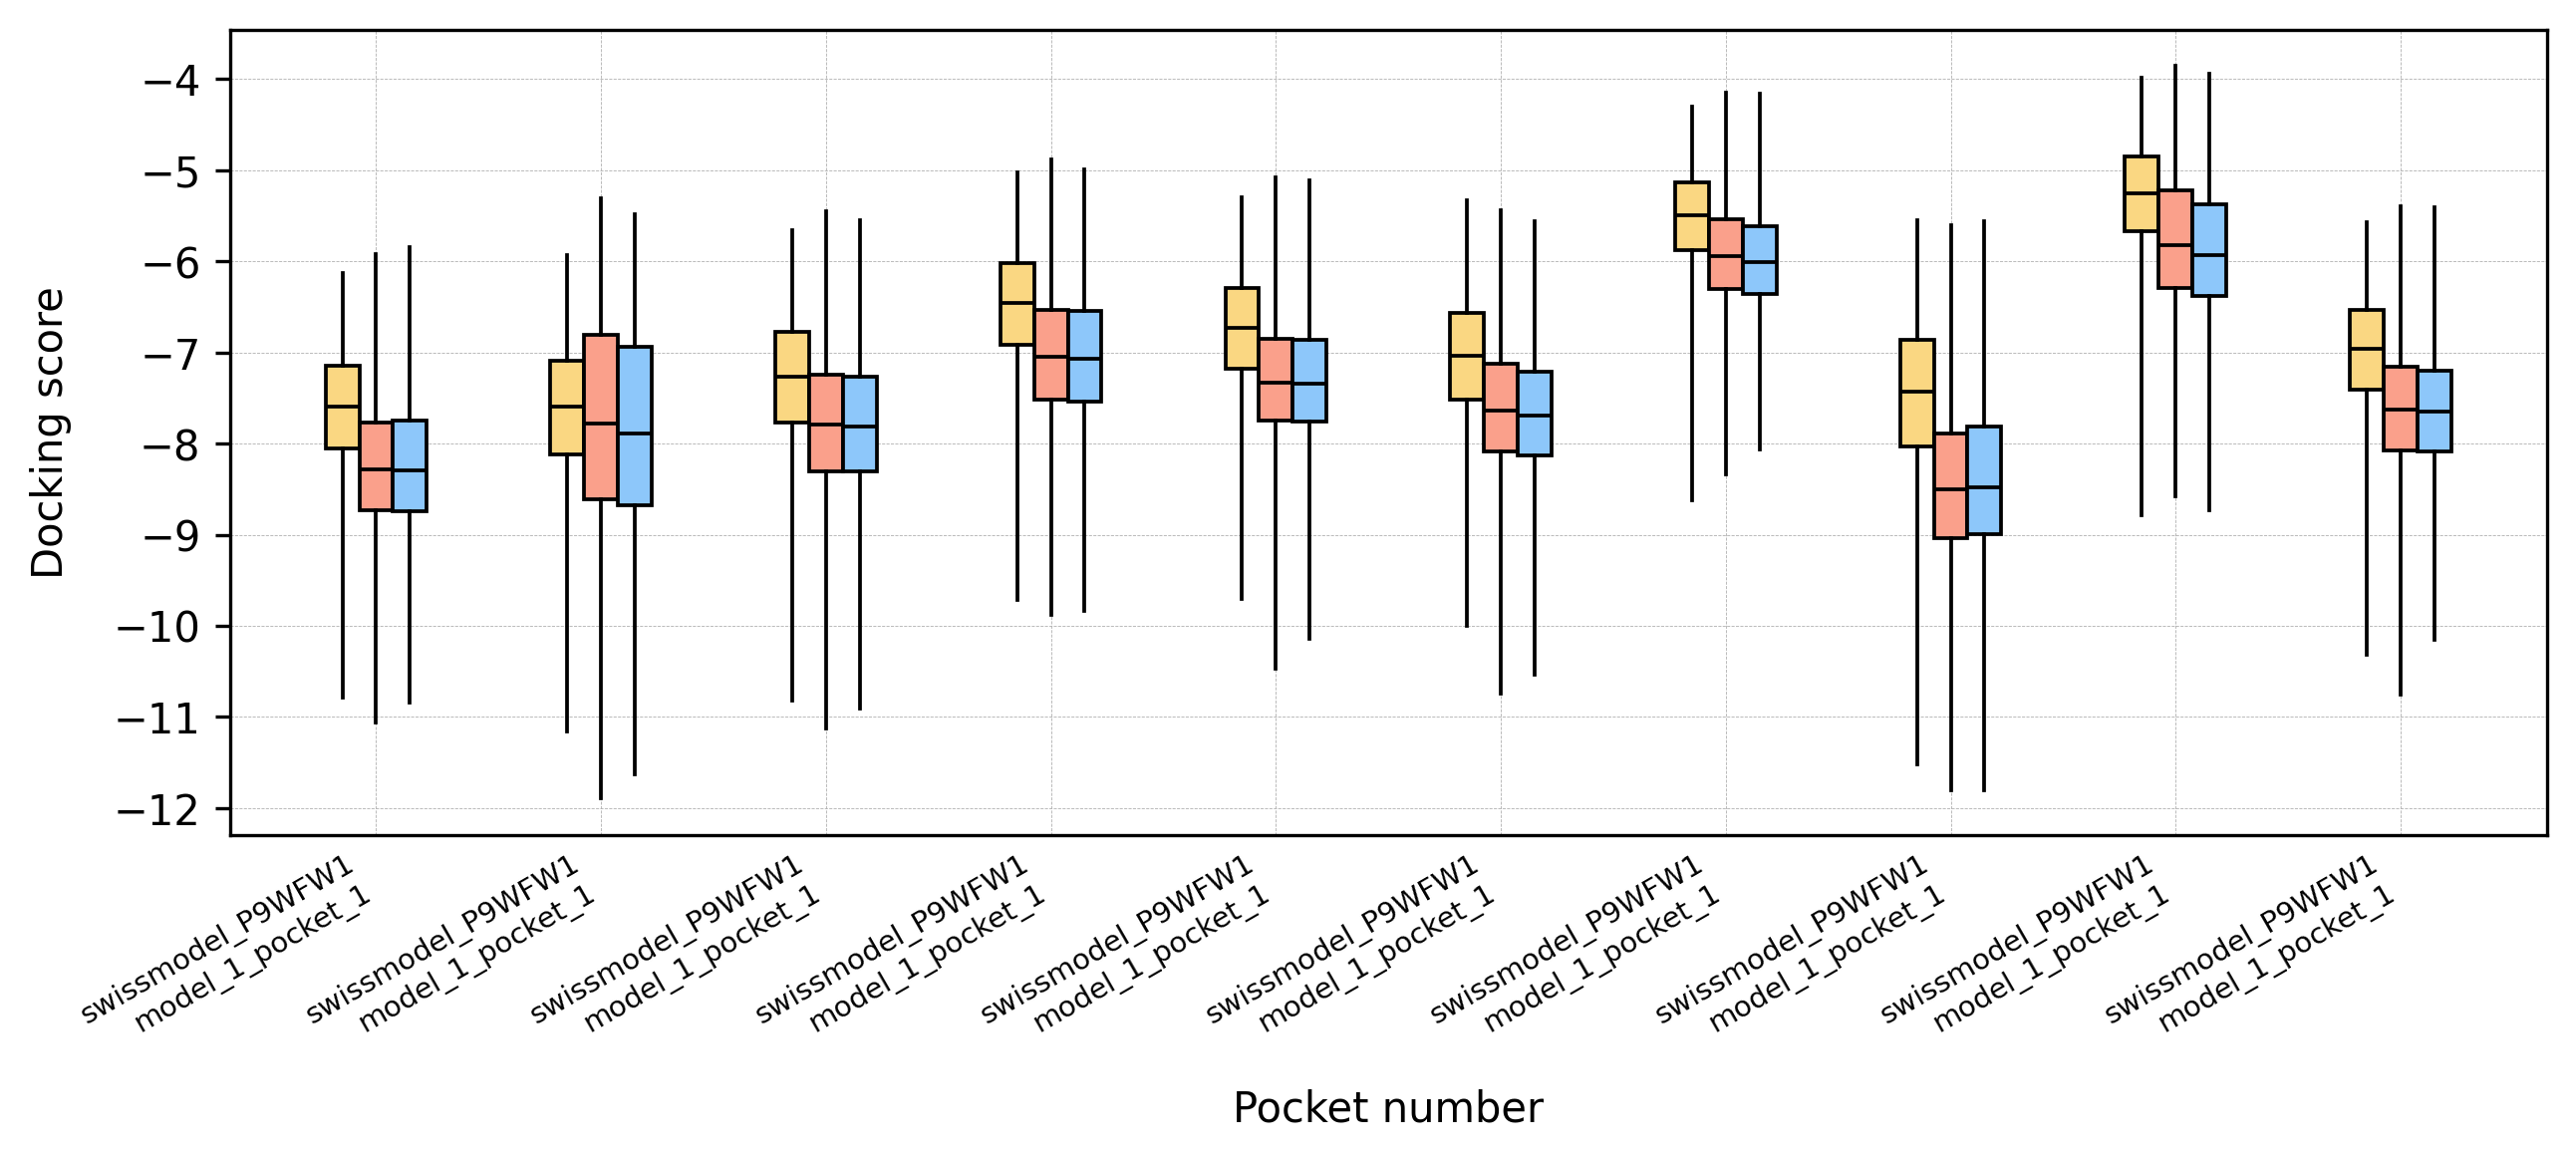

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))

for c, pock in enumerate(sorted(DOCKING_RESULTS_ORIGINAL)):
    w = 0.15
    simple_boxplot(ax, c-w, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w)
    simple_boxplot(ax, c, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w)
    simple_boxplot(ax, c+w, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w)

plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], [pock.replace("_model", "\nmodel") for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Docking score", labelpad=10)
plt.show()

In [8]:
pocket = "swissmodel_P9WFW1_model_1_pocket_1"

In [17]:
print("Reading inference results")
PATH_TO_INFERENCES = "/aloy/home/acomajuncosa/Ersilia/mtb/processed/unidock_docking/inferences"

# For each pocket
for pocket in sorted(os.listdir(PATH_TO_INFERENCES)):
    if pocket.replace("_bin_01.csv.gz", "") in POCKETS_TO_ANALYZE:
        print(f"Processing {pocket} ...")
        # Load results
        inf = pd.read_csv(os.path.join(PATH_TO_INFERENCES, pocket))
        inf = {i: j for i,j in zip(inf['ids'], inf['probs'])}
        values = np.array([inf[i] for i in inf])
        ids = np.array([i for i in inf])
        del inf
        break

Reading inference results
Processing alphafold2_P9WFT3_model_0_pocket_1_bin_01.csv.gz ...


In [41]:
k = 100_000
topk_idx = np.argpartition(values, -k)[-k:]
topk_idx = topk_idx[np.argsort(values[topk_idx])[::-1]]
topk_vals = values[topk_idx]

In [43]:
topk_idx

array([8322080, 8957803, 9022491, ...,  541809, 2788337, 2982512],
      shape=(100000,))

In [39]:
np.argmax(values)

np.int64(8322080)

In [45]:
thrs = [i for i in np.arange(-0.01, 1.02, 0.01)]
y, y1 = [], []

for thr in thrs:
    y.append(len(np.where(values < thr)[0]) / len(values))
    y1.append(len(np.where(values[topk_idx] < thr)[0]) / len(values[topk_idx]))


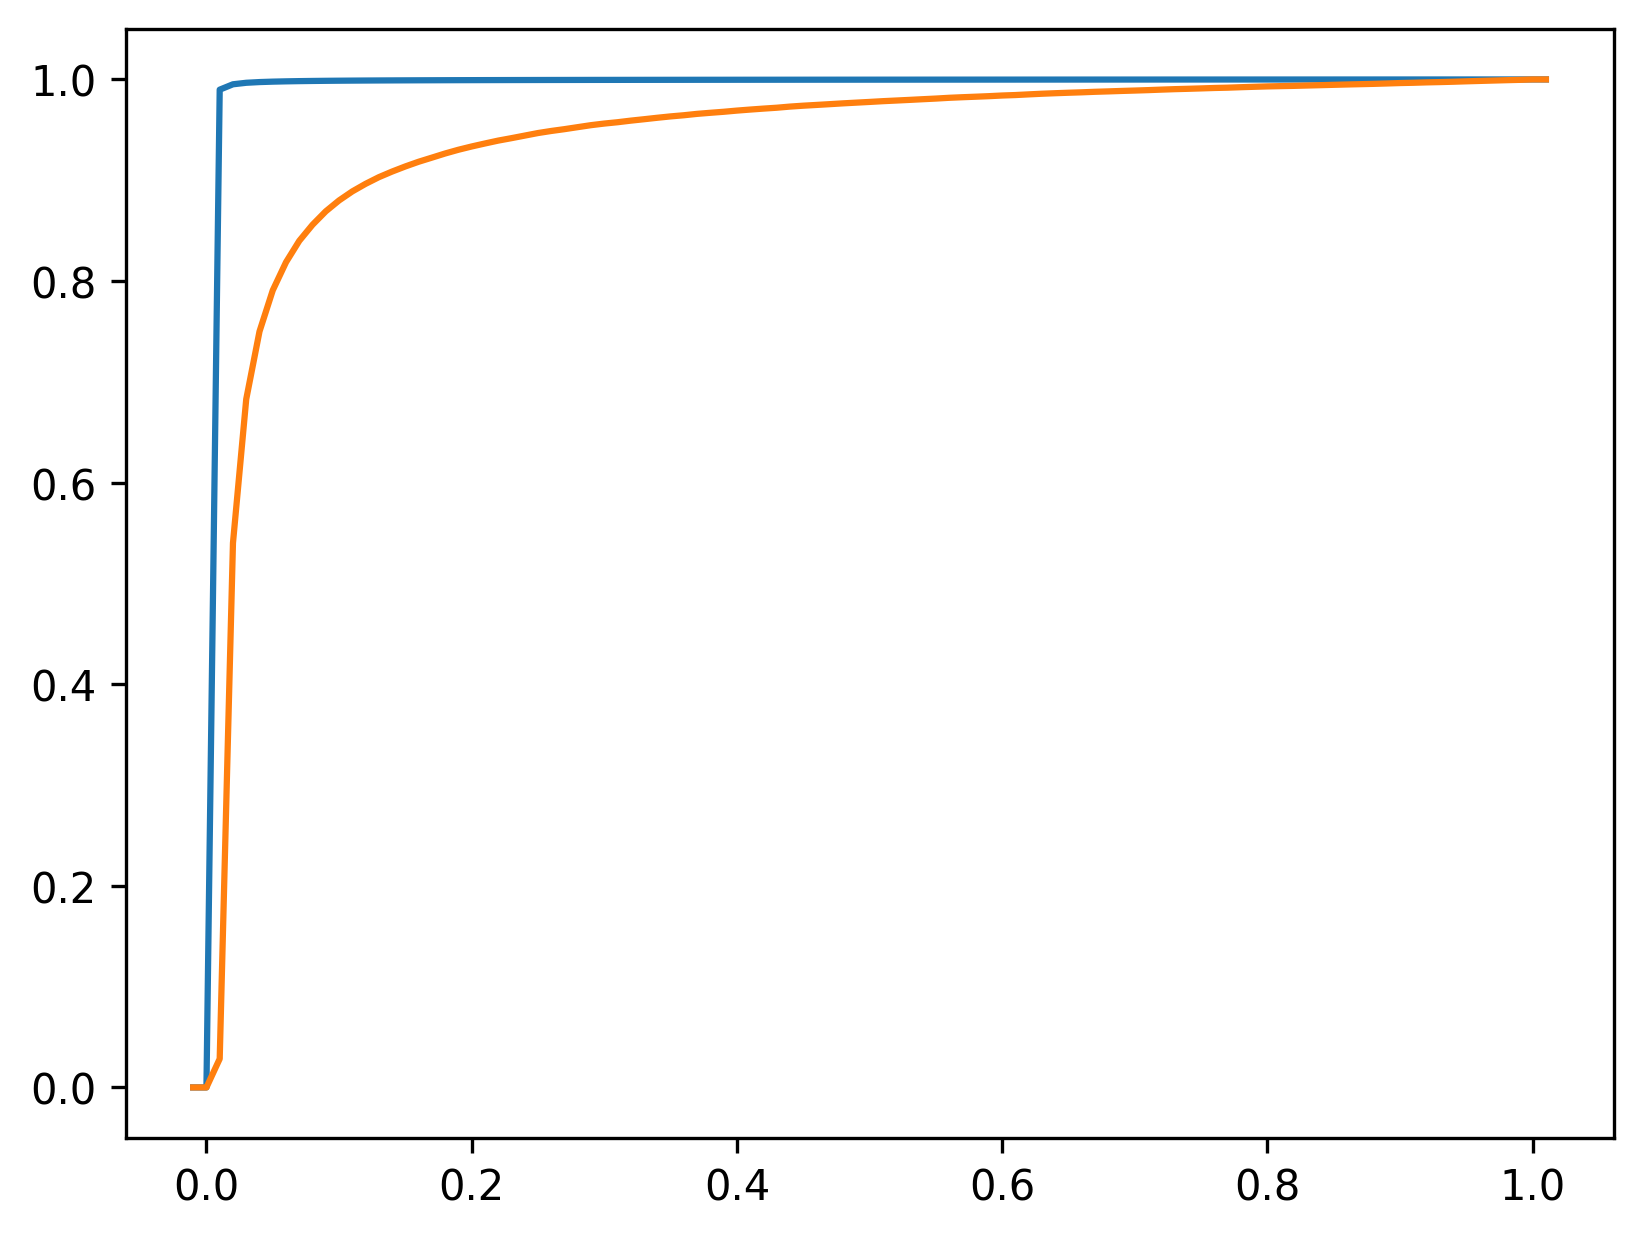

In [47]:
plt.plot(thrs, y)
plt.plot(thrs, y1)
plt.show()